In [421]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,accuracy_score,roc_auc_score,precision_score,f1_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import matplotlib.pyplot as plt
import joblib



In [422]:
df=pd.read_csv("Fraud_Analysis_Dataset.csv")

In [423]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0


In [424]:
df.shape

(11142, 10)

In [425]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')

In [426]:
df.head(40)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1
5,1,CASH_OUT,20128.00,C1118430673,20128.00,0.00,C339924917,6268.00,12145.85,1
6,1,CASH_OUT,416001.33,C749981943,0.00,0.00,C667346055,102.00,9291619.62,1
7,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.00,C431687661,0.00,0.00,1
8,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.00,C716083600,0.00,2444985.19,1
9,1,TRANSFER,35063.63,C1364127192,35063.63,0.00,C1136419747,0.00,0.00,1


In [427]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0
11141,7,PAYMENT,9235.58,C1637966097,39963.00,30727.42,M609545864,0.00,0.00,0


In [428]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [429]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  str    
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  str    
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  str    
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 1.1 MB


In [430]:
df.describe(include="O")

C:\Users\karth\AppData\Local\Temp\ipykernel_28416\504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,type,nameOrig,nameDest
count,11142,11142,11142
unique,5,11142,7508
top,PAYMENT,C1305486145,C985934102
freq,5510,1,62


In [431]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [432]:
df["type"].value_counts()

type
PAYMENT     5510
CASH_IN     1951
CASH_OUT    1871
TRANSFER    1464
DEBIT        346
Name: count, dtype: int64

In [433]:
df[df["isFraud"]==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...
1137,95,CASH_OUT,56745.14,C526144262,56745.14,0.0,C79051264,51433.88,108179.02,1
1138,95,TRANSFER,33676.59,C732111322,33676.59,0.0,C1140210295,0.00,0.00,1
1139,95,CASH_OUT,33676.59,C1000086512,33676.59,0.0,C1759363094,0.00,33676.59,1
1140,95,TRANSFER,87999.25,C927181710,87999.25,0.0,C757947873,0.00,0.00,1


In [434]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: isFraud, dtype: int64

In [435]:

#Fraud mostly happens in CASH_OUT and TRANSFER.
#Fraud almost none is CASH_IN,DEBIT and PAYMENT.

In [436]:
df["type"].value_counts()

type
PAYMENT     5510
CASH_IN     1951
CASH_OUT    1871
TRANSFER    1464
DEBIT        346
Name: count, dtype: int64

In [437]:
fraud_rate = df.groupby('type')['isFraud'].mean() * 100

print(fraud_rate)
#TRANSFER has the highest fraud Probability.


type
CASH_IN      0.000000
CASH_OUT    30.892571
DEBIT        0.000000
PAYMENT      0.000000
TRANSFER    38.524590
Name: isFraud, dtype: float64


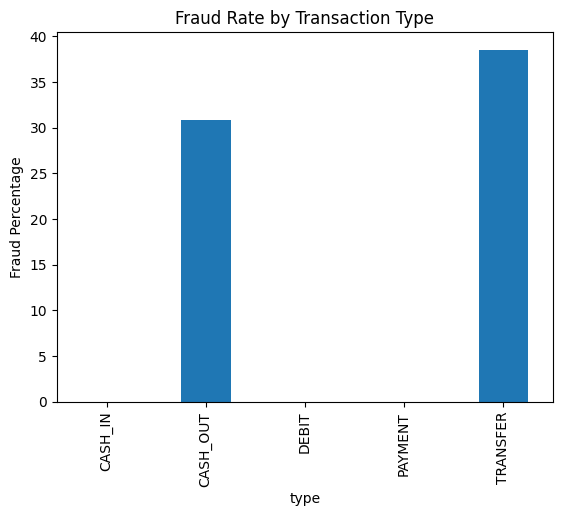

In [438]:


fraud_rate.plot(kind='bar')

plt.ylabel("Fraud Percentage")
plt.title("Fraud Rate by Transaction Type")
plt.show()

In [439]:
#Fraud Count Table
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1951,0
CASH_OUT,1293,578
DEBIT,346,0
PAYMENT,5510,0
TRANSFER,900,564


In [440]:
#Fraud mainly happens in TRANSFER,CASH_OUT.
#WHY THESE TWO?
#BECAUSE OF SCAMMERS.
#CASH-OUT: Refers to withdrawing cash from an account, usually removing funds.
#TRANSFER: Refers to moving money from one account to another, often between accounts held by the same person or entity.
#TRANSFER MONEY.
#IMMEDIATELY CASH OUT
#WHILE OTHERS HAVE VERY LOW FRAUD RATE.
#TRANSFER
#A TRANSFER MOVES MONEY FROM ONE ACCOUNT TO ANOTHER ACCOUNT.
#VICTIM ACCOUNT -> FRAUDSTER ACCOUNT.
#Scammers often steal Login credentials,Access victim's bank Account,Transfer money to Fake Accounts.
#The goal here is:
#Move money away quickly,split money across different accounts.
#CASHOUT
#After transferring stolen money,stealers usually try to withdraw it.
#This removes the traceable digital money and converts it into Physical Form.
#Fraud Detection:
#Large TRANSFER amount -> Suspicious.
#Transfer + Cashout(Immediate) ->Highly Suspicious.
#Emptying Account Balance -> Suspicious.
#Unusual transaction timing -> Suspicious.
#This feature is very important.

In [441]:
df[df['isFraud'] == 1].groupby('step')['isFraud'].count()

step
1     16
2      8
3      4
4     10
5      6
      ..
91     8
92    10
93    16
94    12
95     8
Name: isFraud, Length: 95, dtype: int64

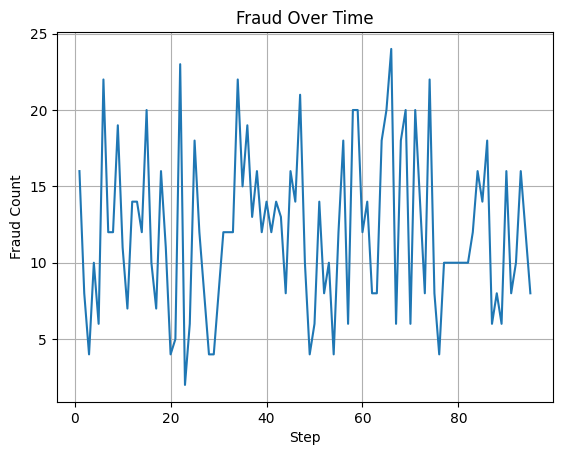

In [442]:


fraud_by_step = df[df['isFraud'] == 1].groupby('step')['isFraud'].sum()

fraud_by_step.plot()

plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.title("Fraud Over Time")
plt.grid()
plt.show()

#This helps identify
#Fraud Spikes.
#Peak attack periods.


In [443]:
#Fraud often depends on timing patterns.
#Banks Analyze:
#When Transactions Occur.
#How frequently they occur.
#Sudden bursts of Activity.
#LIKELY TO OCCUR.
#Immediate CASH_OUT After TRANSFER.
#Multiple Transactions in Short Time.
#This means Account Takeover,Bot Activity.
#Fraud Sometimes increases during:
#Late Night.
#Early Morning
#Because users are less Active on these times.
#for ML Model
#High amount+ TRANSFER + odd hour = suspicious

In [444]:
df["step"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95])

In [445]:
df.groupby(['step', 'type'])['isFraud'].sum()
#Which Transaction Type.
#At What Time.
#Had Fraud.

step  type    
1     CASH_IN     0
      CASH_OUT    9
      DEBIT       0
      PAYMENT     0
      TRANSFER    7
                 ..
93    TRANSFER    8
94    CASH_OUT    6
      TRANSFER    6
95    CASH_OUT    4
      TRANSFER    4
Name: isFraud, Length: 211, dtype: int64

In [446]:
pd.crosstab(df['step'], df['type'])
#How transaction types vary over time

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
step,,,,,
1,527,388,148,1369,276
2,203,104,71,555,81
3,124,52,25,316,35
4,136,77,16,294,42
5,131,61,24,419,30
...,...,...,...,...,...
91,0,4,0,0,4
92,0,5,0,0,5
93,0,8,0,0,8


In [447]:
#oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest.
#oldbalanceOrg:Sender Balance Before transaction.
#newbalanceOrg:Sender balance After transaction.
#oldbalanceDest:Receiver Balance Before transaction.
#newbalanceDest:Receiver Balance After Transaction.

#SENDER --MONEY-----> #RECEIVER.
#Sender
#newbalanceOrg=oldbalanceOrg-Amount.
#Receiver
#newbalance=oldbalanceDest+Amount.

#Account Emptied.
#OldbalanceOrg    #amount      newbalanceOrig
#8000             8000            0
#Fraudsters often do this.
#Balance Mismatch.
#10000            5000             9500
#But the Actual value is 5000.
#This can happen.
#Fraud Attempt.
#Data Manipulation.
#Receiver Balance Not Updated.
#1000              5000        1000
#Receiver balance unchanged.
#Failed Transaction



In [448]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0


In [449]:
df["type"]=df["type"].map({"DEBIT":0,"TRANSFER":1,"CASH_OUT":2,"CASH_IN":3,"PAYMENT":4})

In [450]:
df["type"].value_counts()

type
4    5510
3    1951
2    1871
1    1464
0     346
Name: count, dtype: int64

In [451]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')

In [452]:
df["isFraud"].value_counts() #This is an imbalanced Dataset.

isFraud
0    10000
1     1142
Name: count, dtype: int64

In [453]:
#Transaction Count per Sender
df['original_transaction_count'] = df.groupby('nameOrig')['nameOrig'].transform('count')

In [454]:
df["original_transaction_count"].value_counts()

original_transaction_count
1    11142
Name: count, dtype: int64

In [455]:
df['destination_transaction_count'] = df.groupby('nameDest')['nameDest'].transform('count')

In [456]:
df["destination_transaction_count"].value_counts()
#How many times each destination account appears in the dataset.
#Many destination accounts received only 1 transaction.
#Some received multiple transactions.

#from this the model we can learn
#one destination receiving many rapid transactions.
#unusually high transaction frequency.
#The model can learn:
#normal account behaviour.
#suspicious repeated accounts.

#High transaction count does NOT automatically mean fraud.
#But combined with:
#amount
#timing
#balance changes
#transaction type
#it becomes a powerful fraud signal.


destination_transaction_count
1     6907
2      334
3      306
5      295
4      272
7      231
6      216
20     160
12     144
8      136
10     120
40     120
9      117
39     117
27     108
33      99
18      90
30      90
44      88
29      87
43      86
19      76
15      75
11      66
16      64
21      63
62      62
28      56
52      52
13      52
50      50
41      41
37      37
36      36
35      35
17      34
34      34
32      32
31      31
14      28
26      26
24      24
23      23
22      22
Name: count, dtype: int64

In [457]:
df['destination_average_amount'] = df.groupby('nameDest')['amount'].transform('mean')
#Average transaction amount received by each destination account.
#This helps detect:

#unusual transaction sizes
#abnormal destination behavior

#Example:

#normal average = ₹500
#suddenly receives ₹5,00,000

#suspicious.

#Feature	What It Captures
#transaction_count	frequency behavior
#total_amount	cumulative money flow
#average_amount	normal transaction pattern

In [458]:
df["destination_average_amount"]

0         40140.95
1           181.00
2          2806.00
3          2806.00
4         20128.00
           ...    
11137      6393.71
11138    501355.45
11139    423159.63
11140      1094.03
11141      9235.58
Name: destination_average_amount, Length: 11142, dtype: float64

In [459]:
df['destination_total_amount'] = df.groupby('nameDest')['amount'].transform('sum')
#total amount received by each destination accounts.
#Fraud accounts may:

#receive unusually high total money
#accumulate suspicious funds

#The model learns:

#normal destination behavior
#abnormal destination behavior

In [460]:
df["destination_total_amount"]

0         120422.85
1            181.00
2           2806.00
3           2806.00
4          20128.00
            ...    
11137       6393.71
11138    1002710.90
11139     423159.63
11140       1094.03
11141       9235.58
Name: destination_total_amount, Length: 11142, dtype: float64

In [461]:
df['original_total_amount'] = df.groupby('nameOrig')['amount'].transform('sum')

In [462]:
df["original_total_amount"]

0           181.00
1           181.00
2          2806.00
3          2806.00
4         20128.00
           ...    
11137      6393.71
11138    298799.54
11139    423159.63
11140      1094.03
11141      9235.58
Name: original_total_amount, Length: 11142, dtype: float64

In [463]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,original_transaction_count,destination_transaction_count,destination_average_amount,destination_total_amount,original_total_amount
0,1,1,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,1,3,40140.95,120422.85,181.00
1,1,2,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,1,1,181.00,181.00,181.00
2,1,1,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,1,1,2806.00,2806.00,2806.00
3,1,2,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,1,1,2806.00,2806.00,2806.00
4,1,1,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,1,1,20128.00,20128.00,20128.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,0,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0,1,1,6393.71,6393.71,6393.71
11138,7,2,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0,1,2,501355.45,1002710.90,298799.54
11139,7,2,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0,1,1,423159.63,423159.63,423159.63
11140,7,4,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0,1,1,1094.03,1094.03,1094.03


In [464]:
df[["amount","original_total_amount"]]

,amount,original_total_amount
0,181.00,181.00
1,181.00,181.00
2,2806.00,2806.00
3,2806.00,2806.00
4,20128.00,20128.00
...,...,...
11137,6393.71,6393.71
11138,298799.54,298799.54
11139,423159.63,423159.63
11140,1094.03,1094.03


In [465]:
df.drop(columns=["original_total_amount"],inplace=True)

In [466]:
df.drop(['nameOrig','nameDest'], axis=1, inplace=True)

In [467]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,original_transaction_count,destination_transaction_count,destination_average_amount,destination_total_amount
0,1,1,181.00,181.00,0.00,0.00,0.00,1,1,3,40140.95,120422.85
1,1,2,181.00,181.00,0.00,21182.00,0.00,1,1,1,181.00,181.00
2,1,1,2806.00,2806.00,0.00,0.00,0.00,1,1,1,2806.00,2806.00
3,1,2,2806.00,2806.00,0.00,26202.00,0.00,1,1,1,2806.00,2806.00
4,1,1,20128.00,20128.00,0.00,0.00,0.00,1,1,1,20128.00,20128.00
...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,0,6393.71,433084.38,426690.68,478421.00,210535.25,0,1,1,6393.71,6393.71
11138,7,2,298799.54,426690.68,127891.14,704355.36,5270364.19,0,1,2,501355.45,1002710.90
11139,7,2,423159.63,127891.14,0.00,610479.00,749621.53,0,1,1,423159.63,423159.63
11140,7,4,1094.03,13918.00,12823.97,0.00,0.00,0,1,1,1094.03,1094.03


In [468]:
df.dtypes

step                               int64
type                               int64
amount                           float64
oldbalanceOrg                    float64
newbalanceOrig                   float64
oldbalanceDest                   float64
newbalanceDest                   float64
isFraud                            int64
original_transaction_count         int64
destination_transaction_count      int64
destination_average_amount       float64
destination_total_amount         float64
dtype: object

In [469]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [470]:
#In Fraud datasets,Large transaction amounts are often genuine and important.
#Fraud transactions mostly occur at high amounts,do not remove them.
#Blindly removing them can reduce fraud detection performance.
#A high amount alone does not mean fraud.
#A low amount alone does not mean fraud.

In [471]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [472]:
#Testing Data
lr = LogisticRegression(class_weight="balanced",max_iter=1000)#to control the maximum number of iterations during training.(max_iter=100).

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1999
           1       0.86      0.96      0.91       230

    accuracy                           0.98      2229
   macro avg       0.93      0.97      0.95      2229
weighted avg       0.98      0.98      0.98      2229

ROC-AUC: 0.9932009483002371


In [473]:
#Training Data
y_train_pred = lr.predict(X_train)
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8001
           1       0.86      0.96      0.90       912

    accuracy                           0.98      8913
   macro avg       0.93      0.97      0.95      8913
weighted avg       0.98      0.98      0.98      8913



In [474]:
dt=DecisionTreeClassifier(class_weight="balanced",random_state=42)

In [475]:
param_grid={
    "max_depth":[5,10,20],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,4,8],
    "criterion":["gini","entropy"]
}
gridSearch=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2)

gridSearch.fit(X_train,y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 4, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [476]:
gridSearch.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [477]:
DTC=DecisionTreeClassifier(criterion="entropy",max_depth=10,min_samples_leaf=1,min_samples_split=2,random_state=42)

In [478]:
DTC.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [479]:
#Testing Data
from sklearn.metrics import classification_report, roc_auc_score

y_pred_dt = DTC.predict(X_test)
y_prob_dt = DTC.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_dt))

print("roc_auc_score:",roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       0.99      0.96      0.97       230

    accuracy                           0.99      2229
   macro avg       0.99      0.98      0.99      2229
weighted avg       0.99      0.99      0.99      2229

roc_auc_score: 0.9820932205233052


In [480]:

#Recall is important Missing a fraud transaction is costly.
#Precision is fewer false fraud alerts.

In [481]:
#Training Data
y_train_pred = DTC.predict(X_train)
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8001
           1       1.00      1.00      1.00       912

    accuracy                           1.00      8913
   macro avg       1.00      1.00      1.00      8913
weighted avg       1.00      1.00      1.00      8913



In [482]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))
#TN:1997 #Genuine transactions correctly classified.
#FP:2 #Only 2 genuine transactions were wrongly flagged as fraud. Low FP is important.fewer unnecessary fraud alerts
#FN:10 #10 fraud transactions were missed. Your FN count is quite low.
#TP:220 #220 fraud transactions correctly detected.

[[1997    2]
 [  10  220]]


In [483]:
rf=RandomForestClassifier(class_weight="balanced",random_state=42)

In [484]:
param_grid={
    "n_estimators":[10,20,50,100],
    "max_depth":[10,20,30],
    "criterion":["gini","entropy"] #(24 grids * 5 fold).
}

gridSearch=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2)

gridSearch.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'n_estimators': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [485]:
gridSearch.best_params_

{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 50}

In [486]:
RFC=RandomForestClassifier(criterion="entropy",max_depth=10,n_estimators=50,random_state=42)

In [487]:
RFC.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [488]:
#Testing Data
RFC.predict(X_test)
y_pred_RFC=RFC.predict(X_test)
y_prob_RFC = DTC.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred_RFC))

print("roc_auc_score:",roc_auc_score(y_test, y_prob_RFC))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1999
           1       1.00      0.94      0.97       230

    accuracy                           0.99      2229
   macro avg       1.00      0.97      0.98      2229
weighted avg       0.99      0.99      0.99      2229

roc_auc_score: 0.9820932205233052


In [489]:
#Training Data
y_train_pred = RFC.predict(X_train)
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8001
           1       1.00      1.00      1.00       912

    accuracy                           1.00      8913
   macro avg       1.00      1.00      1.00      8913
weighted avg       1.00      1.00      1.00      8913



In [490]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_RFC))
#FP:No genuine transaction was marked as fraud.
#FN:13 fraud transactions were missed.
#If avoiding customer inconvenience is priority → this is excellent
#If catching every fraud is priority → you may want to reduce FN further
#FP: Out of predicted positives, how many were actually positive.
#FN: Out of actual positives ,how many were correctly found.
#If we increase the threshold value it can reduce.(#FN decreases).


[[1999    0]
 [  13  217]]


In [491]:
RFC.feature_importances_

array([0.40793372, 0.13943396, 0.03068955, 0.06148486, 0.07739645,
       0.02749027, 0.01456632, 0.        , 0.10104483, 0.10299602,
       0.03696401])

In [492]:
X.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'original_transaction_count',
       'destination_transaction_count', 'destination_average_amount',
       'destination_total_amount'],
      dtype='str')

In [493]:
feature_importances=pd.Series(RFC.feature_importances_,index=X.columns).sort_values(ascending=False)

In [494]:
feature_importances

step                             0.407934
type                             0.139434
destination_average_amount       0.102996
destination_transaction_count    0.101045
newbalanceOrig                   0.077396
oldbalanceOrg                    0.061485
destination_total_amount         0.036964
amount                           0.030690
oldbalanceDest                   0.027490
newbalanceDest                   0.014566
original_transaction_count       0.000000
dtype: float64

In [495]:
joblib.dump(RFC, "fraud_model.pkl")

['fraud_model.pkl']

In [496]:
# joblib.dump(scaler,"scaler_model.pkl")

In [497]:
# 1	1	181.00	C1305486145	181.00	0.00	C553264065	0.00	0.00	1	1	3	40140.95	120422.85	181.00
# 7	0	6393.71	C1331144930	433084.38	426690.68	C684896216	478421.00	210535.25	0	1	1	6393.71	6393.71	6393.71

In [498]:
new_data = pd.DataFrame({
    'step':[7],
    'type':[0],
    'amount': [6393.71],
    'oldbalanceOrg': [433084.38],
    'newbalanceOrig': [426690.68],
    'oldbalanceDest': [478421.00],
    'newbalanceDest': [210535.25],
    'original_transaction_count': [1],
    'destination_transaction_count':[1],
    'destination_average_amount':[6393.71],
    'destination_total_amount':[6393.71]
    
    
})

In [499]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'original_transaction_count', 'destination_transaction_count',
       'destination_average_amount', 'destination_total_amount'],
      dtype='str')

In [500]:
prediction = RFC.predict(new_data)

In [501]:
prediction

array([0])